In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
from google.colab import files
uploaded = files.upload()

Saving top100_ai_tools_2026.csv to top100_ai_tools_2026.csv


In [6]:
df = pd.read_csv("/content/top100_ai_tools_2026.csv")
df.head()

,Rank,Tool_Name,Primary_Category,Sub_Category,Pricing_Model,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,Agentic_Capability_Score,API_Available,Release_Year,Active_Users_Est,Description
0,1,ChatGPT,Conversational AI,General Assistant,Freemium,20.00,1800000000,4.8,9.5,Yes,2022,180000000,"OpenAI's flagship conversational AI for text, ..."
1,2,Gemini,Conversational AI,Multimodal AI,Freemium,19.99,500000000,4.7,9.3,Yes,2023,90000000,Google's multimodal AI integrated with Google ...
2,3,Canva AI,Image Generation,Design Assistant,Freemium,15.00,500000000,4.6,6.0,Yes,2023,170000000,AI design tools integrated in Canva
3,4,Character.AI,Conversational AI,Roleplay & Chat,Freemium,9.99,300000000,4.3,6.0,No,2022,20000000,AI characters for entertainment and roleplay
4,5,Claude,Conversational AI,General Assistant,Freemium,20.00,200000000,4.8,9.4,Yes,2023,50000000,Anthropic's safety-focused AI assistant with l...


In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      500 non-null    int64  
 1   Tool_Name                 500 non-null    object 
 2   Primary_Category          500 non-null    object 
 3   Sub_Category              500 non-null    object 
 4   Pricing_Model             500 non-null    object 
 5   Starting_Price_USD        500 non-null    float64
 6   Monthly_Traffic_Est       500 non-null    int64  
 7   User_Rating               500 non-null    float64
 8   Agentic_Capability_Score  500 non-null    float64
 9   API_Available             500 non-null    object 
 10  Release_Year              500 non-null    int64  
 11  Active_Users_Est          500 non-null    int64  
 12  Description               500 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 50.9+ KB


,0
Rank,0
Tool_Name,0
Primary_Category,0
Sub_Category,0
Pricing_Model,0
Starting_Price_USD,0
Monthly_Traffic_Est,0
User_Rating,0
Agentic_Capability_Score,0
API_Available,0


In [8]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [9]:
df.drop("Agentic_Capability_Score", axis=1, inplace=True)

In [10]:
df.columns

Index(['Rank', 'Tool_Name', 'Primary_Category', 'Sub_Category',
       'Pricing_Model', 'Starting_Price_USD', 'Monthly_Traffic_Est',
       'User_Rating', 'API_Available', 'Release_Year', 'Active_Users_Est',
       'Description'],
      dtype='object')

In [11]:
df["Starting_Price_USD"] = pd.to_numeric(df["Starting_Price_USD"], errors="coerce")
df["Monthly_Traffic_Est"] = pd.to_numeric(df["Monthly_Traffic_Est"], errors="coerce")
df["User_Rating"] = pd.to_numeric(df["User_Rating"], errors="coerce")

In [12]:
df.fillna({
    "Starting_Price_USD": 0,
    "User_Rating": df["User_Rating"].mean(),
    "Monthly_Traffic_Est": df["Monthly_Traffic_Est"].median()
}, inplace=True)

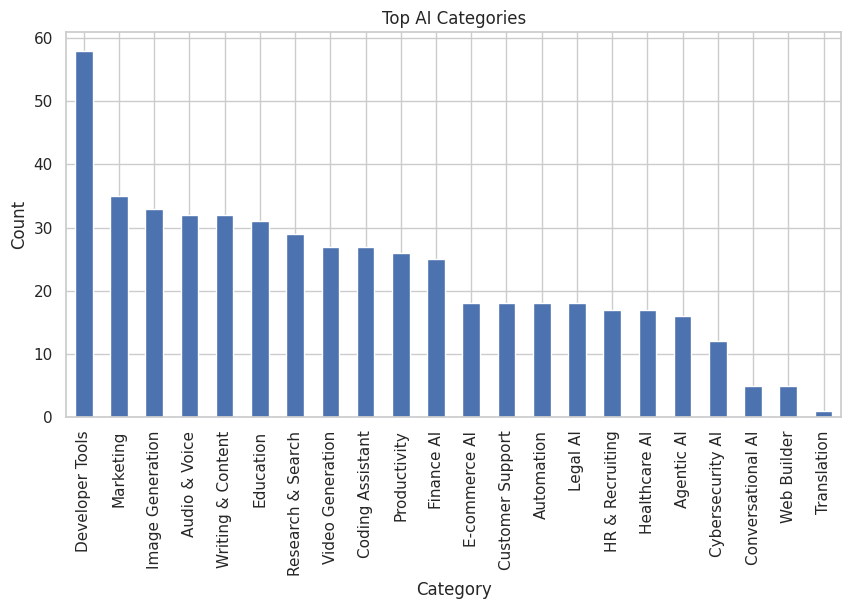

In [13]:
plt.figure(figsize=(10,5))
df["Primary_Category"].value_counts().plot(kind="bar")
plt.title("Top AI Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

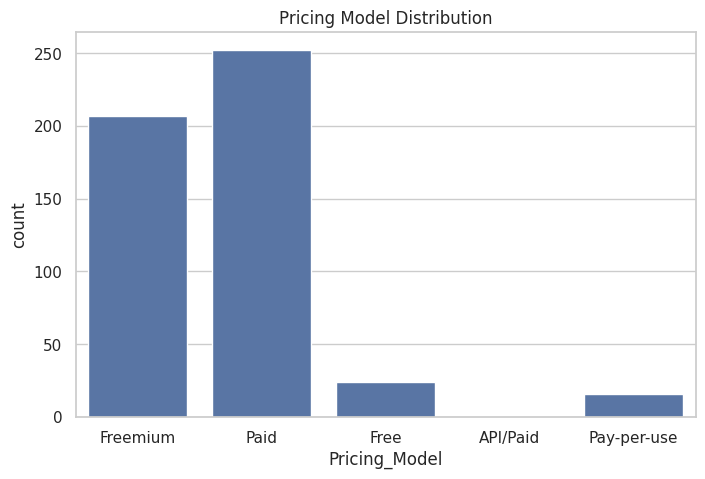

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="Pricing_Model", data=df)
plt.title("Pricing Model Distribution")
plt.show()

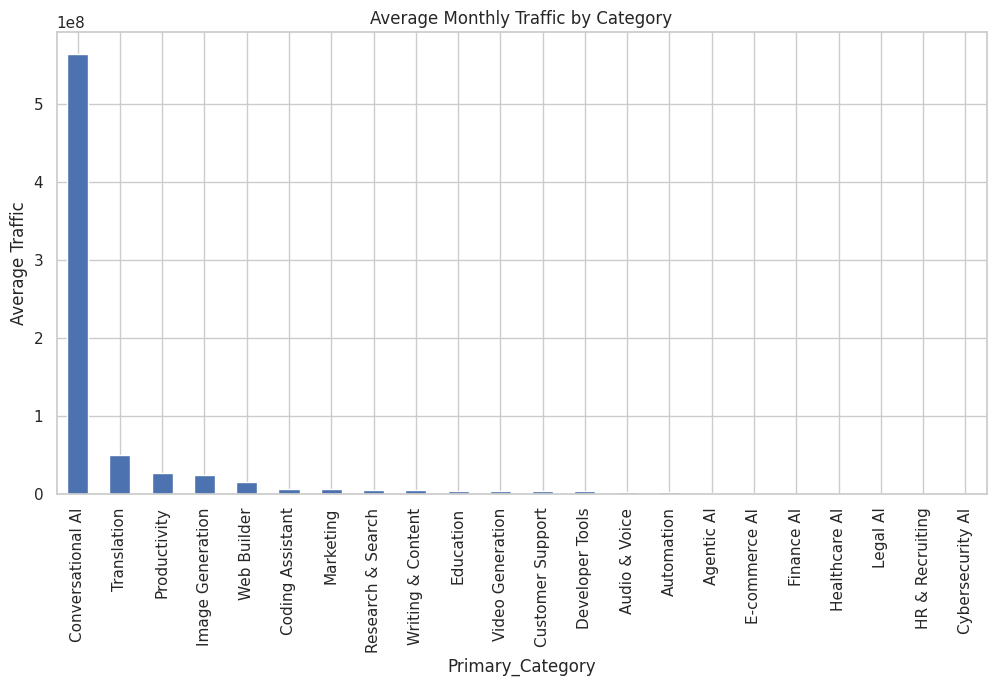

In [15]:
category_traffic = df.groupby("Primary_Category")["Monthly_Traffic_Est"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
category_traffic.plot(kind="bar")
plt.title("Average Monthly Traffic by Category")
plt.ylabel("Average Traffic")
plt.show()

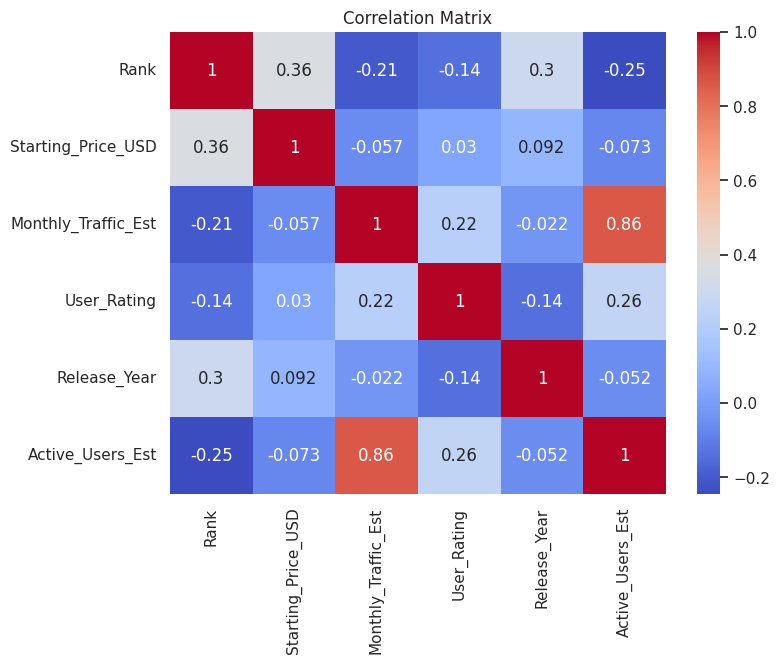

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

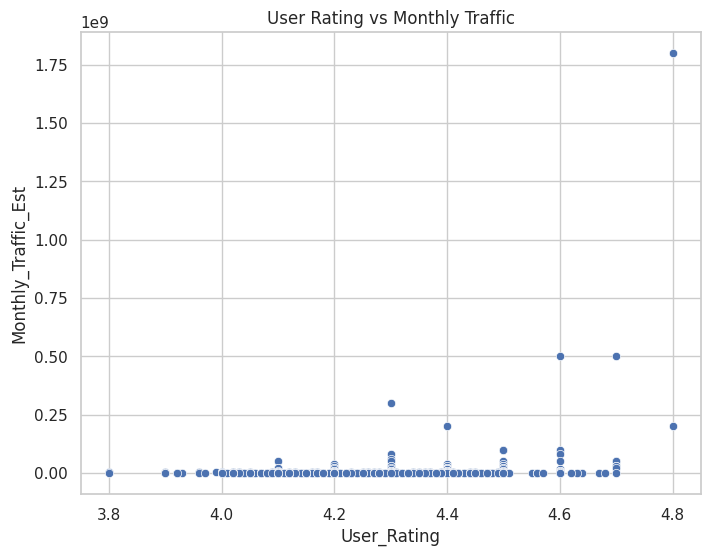

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="User_Rating",
                y="Monthly_Traffic_Est",
                data=df)

plt.title("User Rating vs Monthly Traffic")
plt.show()

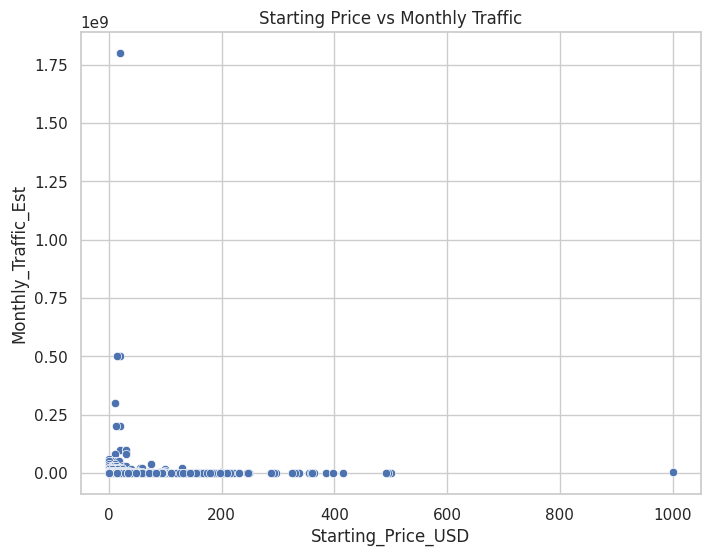

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Starting_Price_USD",
                y="Monthly_Traffic_Est",
                data=df)

plt.title("Starting Price vs Monthly Traffic")
plt.show()

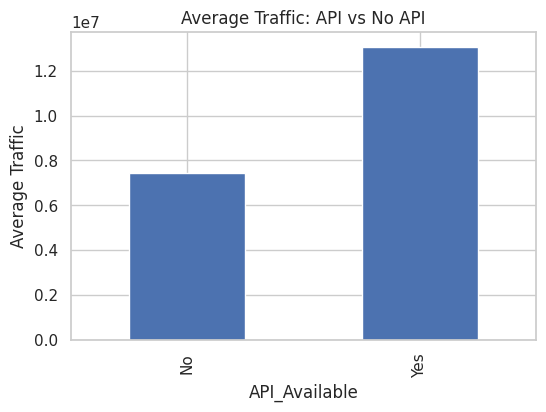

In [20]:
api_traffic = df.groupby("API_Available")["Monthly_Traffic_Est"].mean()

plt.figure(figsize=(6,4))
api_traffic.plot(kind="bar")
plt.title("Average Traffic: API vs No API")
plt.ylabel("Average Traffic")
plt.show()

In [21]:
free_tools = df[df["Pricing_Model"] == "Free"]
free_tools.head()

,Rank,Tool_Name,Primary_Category,Sub_Category,Pricing_Model,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,API_Available,Release_Year,Active_Users_Est,Description
18,19,Stable Diffusion,Image Generation,Open Source Image,Free,0.0,40000000,4.4,Yes,2022,20000000,Open-source text-to-image model by Stability AI
34,35,Pi by Inflection,Conversational AI,Personal Assistant,Free,0.0,20000000,4.4,No,2023,2000000,Personal AI designed for empathetic conversation
44,45,Llama 3,Developer Tools,Open LLM,Free,0.0,15000000,4.6,Yes,2024,5000000,Meta's open-source large language model family
58,59,Socratic by Google,Education,Homework Help,Free,0.0,10000000,4.4,No,2018,5000000,AI homework helper for students
66,67,Whisper,Developer Tools,Speech Recognition,Free,0.0,10000000,4.6,Yes,2022,1000000,OpenAI's open-source speech recognition model


In [22]:
premium_tools = df[df["Starting_Price_USD"] > 20]
premium_tools.head()

,Rank,Tool_Name,Primary_Category,Sub_Category,Pricing_Model,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,API_Available,Release_Year,Active_Users_Est,Description
7,8,Grammarly,Writing & Content,Grammar & Style,Freemium,30.0,100000000,4.5,Yes,2009,30000000,"AI writing assistant for grammar, tone and style"
8,9,Microsoft 365 Copilot,Productivity,Office Suite AI,Paid,30.0,100000000,4.5,Yes,2023,345000,AI assistant across all Microsoft 365 apps
10,11,Teams Copilot,Productivity,Meeting AI,Paid,30.0,80000000,4.3,Yes,2023,300000,Microsoft Copilot integrated in Teams
20,21,Salesforce Einstein,Marketing,CRM AI,Paid,75.0,40000000,4.2,Yes,2016,150000,AI embedded across Salesforce CRM
22,23,Replit AI,Coding Assistant,Cloud IDE,Freemium,25.0,30000000,4.3,Yes,2023,4000000,AI-powered cloud coding environment


In [23]:
top10 = df.sort_values("Monthly_Traffic_Est", ascending=False).head(10)

top10[["Tool_Name", "Monthly_Traffic_Est", "User_Rating"]]

,Tool_Name,Monthly_Traffic_Est,User_Rating
0,ChatGPT,1800000000,4.8
2,Canva AI,500000000,4.6
1,Gemini,500000000,4.7
3,Character.AI,300000000,4.3
5,Google Workspace AI,200000000,4.4
4,Claude,200000000,4.8
7,Grammarly,100000000,4.5
6,Perplexity AI,100000000,4.6
8,Microsoft 365 Copilot,100000000,4.5
9,GitHub Copilot,80000000,4.6


In [24]:
!pip install plotly

In [25]:
import plotly.express as px

fig = px.scatter(df,
                 x="User_Rating",
                 y="Monthly_Traffic_Est",
                 color="Primary_Category",
                 hover_data=["Tool_Name"])

fig.show()